# Imports

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

from ncon import ncon

sys.path.append(
    r"C:\Users\alios\OneDrive - University College London\Desktop\UCL\Year4\year4_project\codes"
)

from my_functions import (
    image_to_hierarchical,
    dense_to_mps_L_canonical,
)

from help_functions_motifs import (
    create_grid,
    plot_save_grid,
    create_superposition_mps,
    plot_motif_reconstruction,
)

# Investigation 1: Applying Rotation Operators to Image-Encoded MPS
### (Quantics Encoding -> Operator Transformation)

---

# Investigation 2: Building Motif Ensembles via Tensor Superposition
### (basic tensors (and their rotations) -> sum state )

---

# Investigation 1: Applying Rotation Operators to Image-Encoded MPS

## Single motif encoding - Rotations

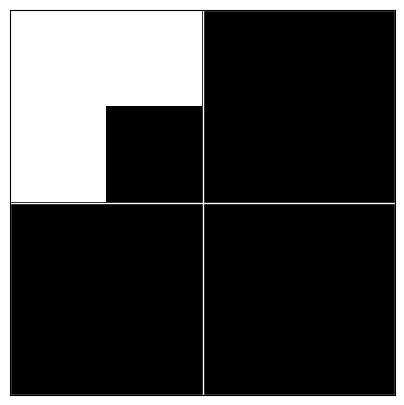

In [3]:
# 2x2 motifs
size_motif = 2
motif0 = np.ones((size_motif, size_motif))
motif0[1, 1] = 0
grid4x4_motif2x2_topleft = create_grid(motif0, 2)

plot_save_grid(
    grid4x4_motif2x2_topleft,
    # title="Original 4x4 grid with 2x2 motif",
    filename="grid4x4_motif2x2_topleft",
    show_ticks=False,
)
plt.show()

In [4]:
# convert motif to mps
hierarchical_motif = image_to_hierarchical(grid4x4_motif2x2_topleft)
mps_grid4x4_motif2x2_topleft, lambdas_motif = dense_to_mps_L_canonical(
    hierarchical_motif, physical_dim=4, bond_dim=1
)
print("Shape of each site in MPS:", [t.shape for t in mps_grid4x4_motif2x2_topleft])

for i, t in enumerate(mps_grid4x4_motif2x2_topleft):
    print(f"Site {i}:")
    print(np.array2string(t, formatter={"float_kind": lambda x: f"{x:.3f}"}))
    print()

Shape of each site in MPS: [(1, 4, 1), (1, 4, 1)]
Site 0:
[[[1.000]
  [0.000]
  [0.000]
  [0.000]]]

Site 1:
[[[0.577]
  [0.577]
  [0.577]
  [0.000]]]



# 90 deegre rotation on site 2
Read operator column wise. Colums 1 goes to position where row is 1, hence position 1 goes to position 2 etc

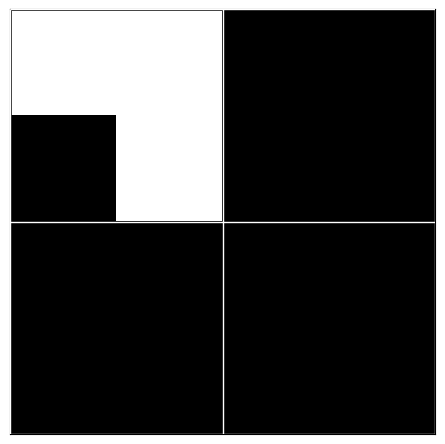

In [5]:
rot_90 = np.array(
    [
        [0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0],
    ]
)
# Apply R
rotated90_motif = ncon(
    [mps_grid4x4_motif2x2_topleft[1], rot_90], [[-1, 1, -3], [-2, 1]]
)


# reconstruct the rotated system
rotated_system = [mps_grid4x4_motif2x2_topleft[0], rotated90_motif]
grid4x4_motif2x2_topleft_rot_site2 = plot_motif_reconstruction(
    rotated_system,
    lambdas=lambdas_motif,
    depth=0,
    # title="Site 2 rotated by 90 degrees",
    title=False,
    show_values=False,
    grid_step=2,
    filename="grid4x4_motif2x2_topleft_rotated90",
)
plt.show()


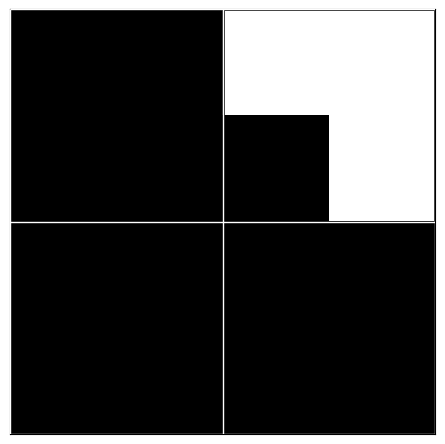

In [6]:
# rotate site 1 and 2
# reconstruct the rotated system
rotated90_site1 = ncon(
    [mps_grid4x4_motif2x2_topleft[0], rot_90], [[-1, 1, -3], [-2, 1]]
)

rotated_system = [rotated90_site1, rotated90_motif]
grid4x4_motif2x2_topleft_rot_site2 = plot_motif_reconstruction(
    rotated_system,
    lambdas=lambdas_motif,
    depth=0,
    # title="Site 1 and 2 rotated by 90 degrees",
    title=False,
    show_values=False,
    grid_step=2,
    filename="grid4x4_motif2x2_topleft_site12_rotated90",
)
plt.show()

## Multiple rotations on site 1

After 90 degrees rotation on first site, site 1 is: [[0.]
 [1.]
 [0.]
 [0.]]
After 180 degrees rotation on first site, site 1 is: [[0.]
 [0.]
 [0.]
 [1.]]
After 270 degrees rotation on first site, site 1 is: [[0.]
 [0.]
 [1.]
 [0.]]
After 360 degrees rotation on first site, site 1 is: [[1.]
 [0.]
 [0.]
 [0.]]


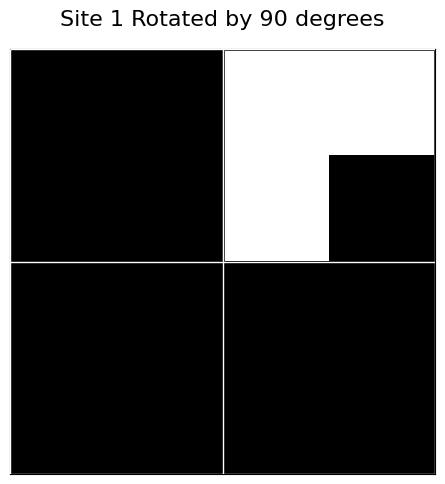

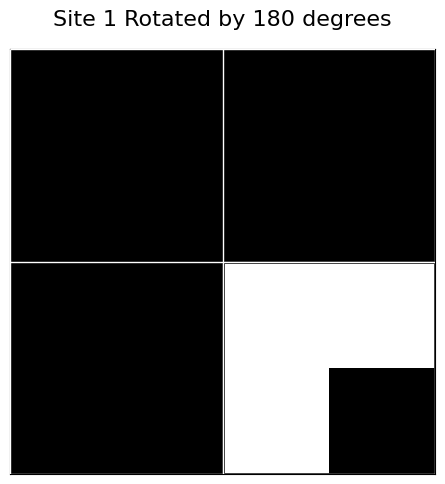

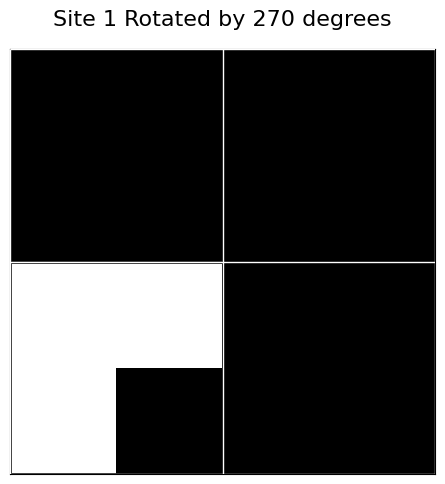

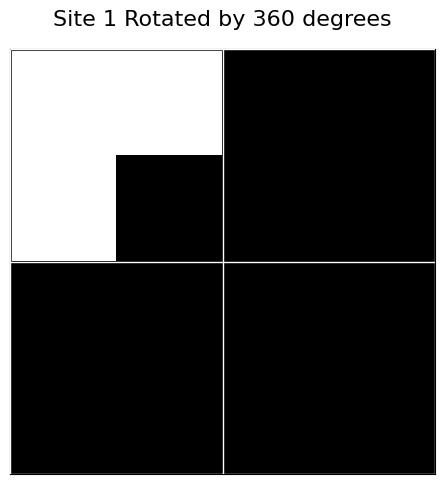

In [7]:
site1 = mps_grid4x4_motif2x2_topleft[0]

for i in range(1, 5):
    # Calculate degrees for the title (90, 180, 270, 360)
    angle = i * 90

    site1_rotated_tmp = site1
    current_rotated_site = ncon([site1_rotated_tmp, rot_90], [[-1, 1, -3], [-2, 1]])
    print(
        f"After {angle} degrees rotation on first site, site 1 is: {current_rotated_site[0]}"
    )

    # Reconstruct the system list
    current_system = [current_rotated_site, mps_grid4x4_motif2x2_topleft[1]]

    site1 = current_rotated_site

    plot_motif_reconstruction(
        current_system,
        lambdas_motif,
        depth=0,
        grid_step=2,
        title=f"Site 1 Rotated by {angle} degrees",
        show_values=False,
        filename=f"grid4x4_motif2x2_topleft_site1_rotated_{angle}_degrees",
    )


The rotation operator acts as a transposition operator !!!
- If R acts on first sites (positioning site) the outcome is a trunsposition
- If R act on teh second site (motif site) the outcome is a rotation in a 2x2 grid 

### pi rotation 

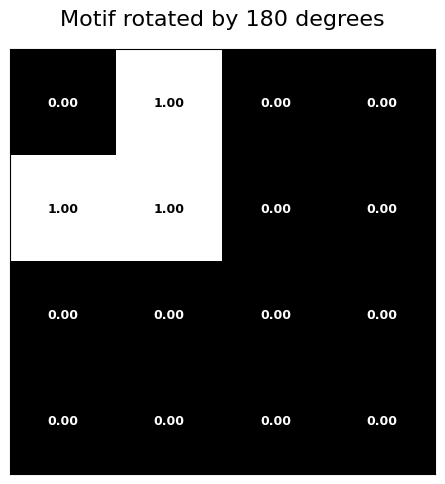

In [8]:
rot_180 = np.array(
    [
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
    ]
)

# Apply R
rotated180_motif = ncon(
    [mps_grid4x4_motif2x2_topleft[1], rot_180], [[-1, 1, -3], [-2, 1]]
)

# reconstruct the rotated system
rotated_system = [mps_grid4x4_motif2x2_topleft[0], rotated180_motif]
grid4x4_motif2x2_topleft_rot_site2 = plot_motif_reconstruction(
    rotated_system, lambdas=lambdas_motif, depth=0, title="Motif rotated by 180 degrees"
)
plt.show()

# Rotations tested on larger grid and on multiple sites 

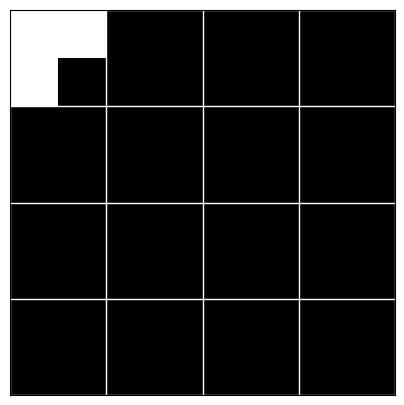

In [9]:
# create motif
size_motif = 2
motif0 = np.ones((size_motif, size_motif))
motif0[1, 1] = 0

cell_size = 2
exponent_size = 3  # 2^3 = 8
row_start = 0
col_start = 0

grid8x8_motif2x2_topleft = create_grid(
    motif0,
    exponent_size=exponent_size,
    row_offset=row_start,
    col_offset=col_start,
)


plot_save_grid(
    grid8x8_motif2x2_topleft,
    # title="Single motif 8x8 grid",
    title=False,
    filename="grid8x8_motif2x2_topleft",
    cell_size=cell_size,
    show_ticks=False,
)

In [10]:
# encode motif into MPS
hierarchical_motif = image_to_hierarchical(grid8x8_motif2x2_topleft)
mps_grid8x8_motif2x2_topleft, lambdas_grid8x8_motif2x2 = dense_to_mps_L_canonical(
    hierarchical_motif, physical_dim=4, bond_dim=1
)
print("Shape of each site in MPS:", [t.shape for t in mps_grid8x8_motif2x2_topleft])
for i, t in enumerate(mps_grid8x8_motif2x2_topleft):
    print(f"Site {i}:")
    print(np.array2string(t, formatter={"float_kind": lambda x: f"{x:.3f}"}))
    print()

# rotate motif via contraction
position_site1 = mps_grid8x8_motif2x2_topleft[0]
rotated_site1 = ncon([position_site1, rot_90], [[-1, 1, -3], [-2, 1]])
print(f"After 90 degrees rotation on first site, site 1 is: {rotated_site1}")
# Reconstruct the system list
rotated_site1_sys_8x8 = [
    rotated_site1,
    mps_grid8x8_motif2x2_topleft[1],
    mps_grid8x8_motif2x2_topleft[2],
]


Shape of each site in MPS: [(1, 4, 1), (1, 4, 1), (1, 4, 1)]
Site 0:
[[[1.000]
  [0.000]
  [0.000]
  [0.000]]]

Site 1:
[[[1.000]
  [0.000]
  [0.000]
  [0.000]]]

Site 2:
[[[0.577]
  [0.577]
  [0.577]
  [0.000]]]

After 90 degrees rotation on first site, site 1 is: [[[0.]
  [1.]
  [0.]
  [0.]]]


In [11]:
# rotate site 2
position_site2 = mps_grid8x8_motif2x2_topleft[1]
rotated_site2 = ncon([position_site2, rot_90], [[-1, 1, -3], [-2, 1]])
print(f"After 90 degrees rotation on second site, site 2 is: {rotated_site2}")
# Reconstruct the system list
rotated_site12_sys_8x8 = [
    rotated_site1,
    rotated_site2,
    mps_grid8x8_motif2x2_topleft[2],
]

# rotate site 3
position_site3 = mps_grid8x8_motif2x2_topleft[2]
rotated_site3 = ncon([position_site3, rot_90], [[-1, 1, -3], [-2, 1]])
# Reconstruct the system list
rotated_site123_sys_8x8 = [rotated_site1, rotated_site2, rotated_site3]


# rotate site 1 and 3
rotated_site13_sys_8x8 = [
    rotated_site1,
    mps_grid8x8_motif2x2_topleft[1],
    rotated_site3,
]


After 90 degrees rotation on second site, site 2 is: [[[0.]
  [1.]
  [0.]
  [0.]]]


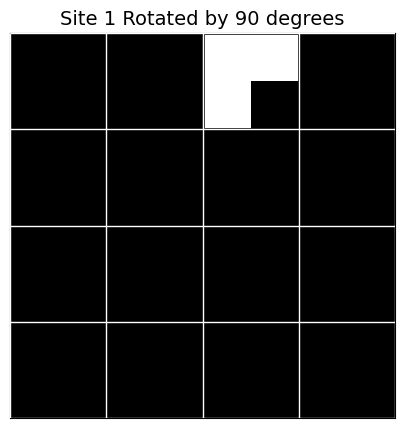

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))

plot_motif_reconstruction(
    rotated_site1_sys_8x8,
    lambdas_grid8x8_motif2x2,
    depth=0,
    show_values=False,
    grid_step=2,
    title=f"Site 1 Rotated by 90 degrees",
    target_axes=[ax],
)
plt.savefig("plots/8x8grid_site1_rotated.png", dpi=600, bbox_inches="tight")
plt.show()

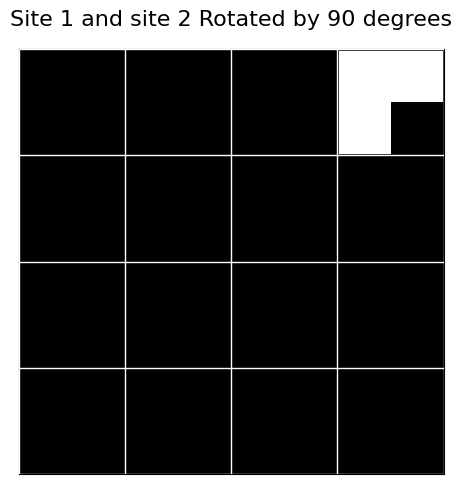

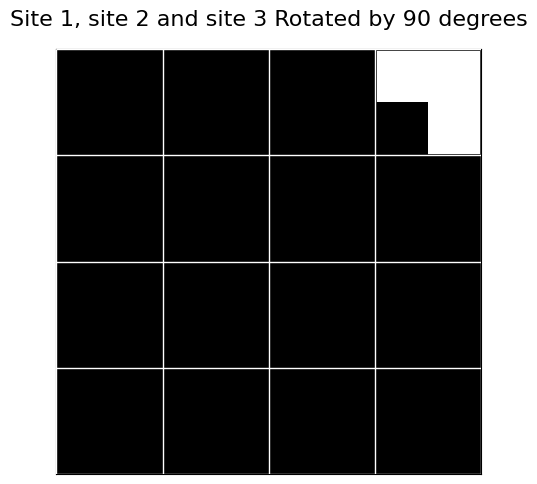

In [13]:
# otehr site rotations
plot_site12_rotated = plot_motif_reconstruction(
    rotated_site12_sys_8x8,
    lambdas_grid8x8_motif2x2,
    depth=0,
    show_values=False,
    grid_step=2,
    title=f"Site 1 and site 2 Rotated by 90 degrees",
)
plt.savefig("plots/8x8grid_site12_rotated.png", dpi=600, bbox_inches="tight")

plot_site123_rotated = plot_motif_reconstruction(
    rotated_site123_sys_8x8,
    lambdas_grid8x8_motif2x2,
    depth=0,
    show_values=False,
    grid_step=2,
    title=f"Site 1, site 2 and site 3 Rotated by 90 degrees",
)

plt.savefig("plots/8x8grid_site123_rotated.png", dpi=600, bbox_inches="tight")

<div class="alert alert-danger">
End investigation 1
</div>

----

# Investigation 2: Building Motif Ensembles via Tensor Superposition
### (basic tensors (and their rotations) -> sum state )

## 8x8 grid, 4x4 motif rotations

Shape of each site in syntethic MPS: [(1, 4, 1), (1, 4, 1), (1, 4, 1)]


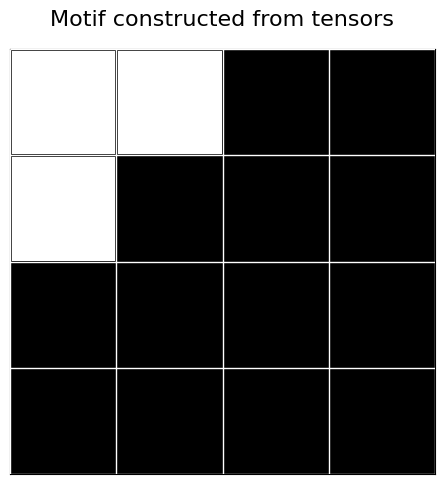

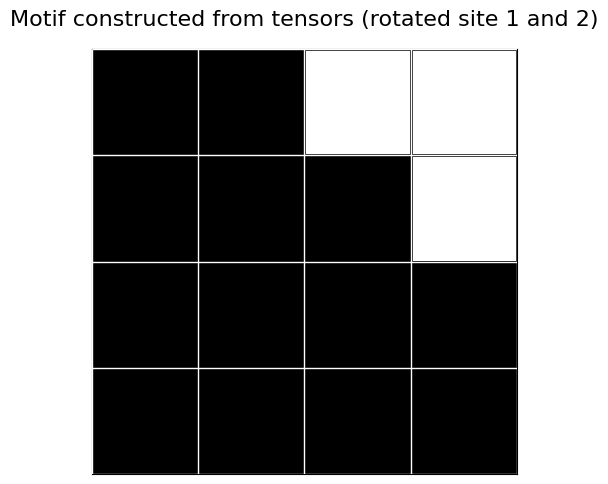

In [14]:
motif_tensor = np.array([[[1], [1], [1], [0.0]]])
position_tensor = np.array([[[1.0], [0.0], [0.0], [0.0]]])
filler_tensor = np.array([[[1.0], [1.0], [1.0], [1.0]]])

# all possible rotations of each tensor
pos_R = ncon([position_tensor, rot_90], [[-1, 1, -3], [-2, 1]])
pos_RR = ncon([pos_R, rot_90], [[-1, 1, -3], [-2, 1]])
pos_RRR = ncon([pos_RR, rot_90], [[-1, 1, -3], [-2, 1]])

# rotated motifs
motif_R = ncon([motif_tensor, rot_90], [[-1, 1, -3], [-2, 1]])
motif_RR = ncon([motif_R, rot_90], [[-1, 1, -3], [-2, 1]])
motif_RRR = ncon([motif_RR, rot_90], [[-1, 1, -3], [-2, 1]])


# construct MPS for motif at topleft position
mps_grid8x8_motif4x4_topleft = [position_tensor, motif_tensor, filler_tensor]
rotated_site2 = ncon([mps_grid8x8_motif4x4_topleft[1], rot_90], [[-1, 1, -3], [-2, 1]])
rotated_site1 = ncon([mps_grid8x8_motif4x4_topleft[0], rot_90], [[-1, 1, -3], [-2, 1]])
mps_grid8x8_motif4x4_topleft_rotated_site12 = [
    pos_R,
    motif_R,
    filler_tensor,
]


print(
    "Shape of each site in syntethic MPS:",
    [t.shape for t in mps_grid8x8_motif4x4_topleft],
)
madeup_lambda = np.array([1])

syntethic_grid = plot_motif_reconstruction(
    mps_grid8x8_motif4x4_topleft,
    lambdas=madeup_lambda,
    depth=0,
    title="Motif constructed from tensors",
    show_values=False,
    grid_step=2,
)

syntethic_grid_rotated_site12 = plot_motif_reconstruction(
    mps_grid8x8_motif4x4_topleft_rotated_site12,
    lambdas=madeup_lambda,
    depth=0,
    title="Motif constructed from tensors (rotated site 1 and 2)",
    show_values=False,
    grid_step=2,
)

# example for disseratation
Encoding of a fractal 

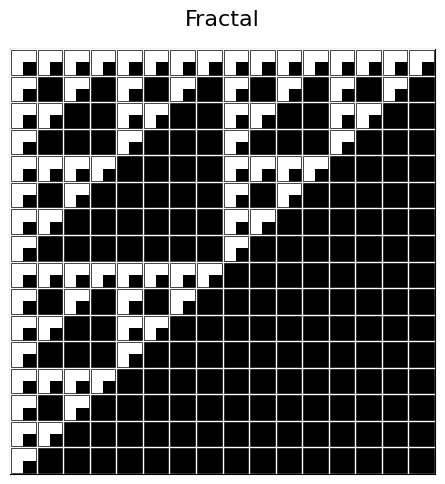

In [15]:
# mps_fractal = [motif_tensor, motif_tensor, motif_tensor]
mps_fractal = [motif_tensor, motif_tensor, motif_tensor, motif_tensor, motif_tensor]

_ = plot_motif_reconstruction(
    mps_fractal,
    lambdas=madeup_lambda,
    depth=0,
    title="Fractal",
    show_values=False,
    grid_step=2,
    filename="fractal_motif.png",
)

## Rescaling on a 8x8 grid

In [16]:
# 2x2, 4x4, and 8x8 motif ensembles
mps_grid8x8_motif2x2_topleft

mps_grid8x8_motif4x4_topleft = [position_tensor, motif_tensor, filler_tensor]
mps_grid8x8_motif8x8_topleft = [motif_tensor, filler_tensor, filler_tensor]

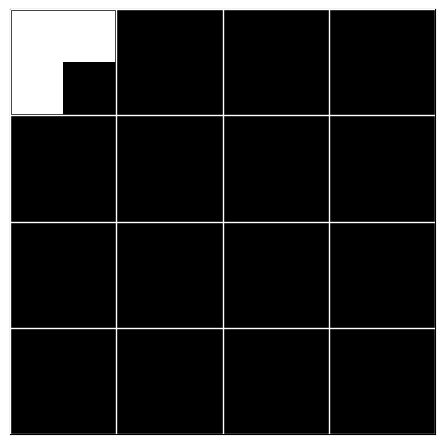

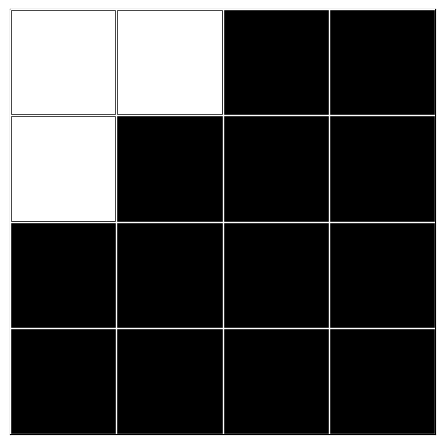

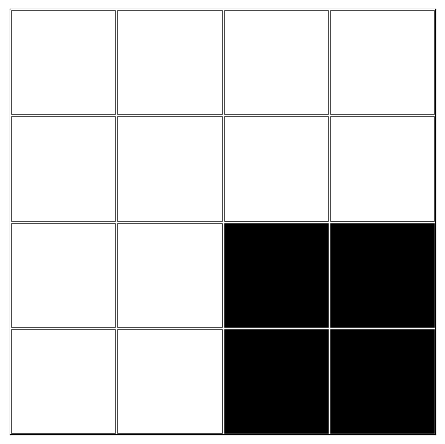

In [63]:
# fig, all_axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 8))
_ = plot_motif_reconstruction(
    mps_grid8x8_motif2x2_topleft,
    lambdas_grid8x8_motif2x2,
    depth=0,
    show_values=False,
    title=False,
    grid_step=2,
)

_ = plot_motif_reconstruction(
    mps_grid8x8_motif4x4_topleft,
    lambdas_grid8x8_motif2x2,
    depth=0,
    show_values=False,
    title=False,
    grid_step=2,
    filename="scaled_4x4_motif.png",
)


_ = plot_motif_reconstruction(
    mps_grid8x8_motif8x8_topleft,
    lambdas_grid8x8_motif2x2,
    depth=0,
    show_values=False,
    title=False,
    grid_step=2,
    filename="scaled_8x8_motif.png",
)


# all_axes[0].set_title("Original Motif in 8x8 Grid")
# all_axes[1].set_title("Scaled Motif x2")
# all_axes[2].set_title("Scaled Motif x4")

# fig.colorbar(
#     ims_original_motif[0], ax=all_axes.ravel().tolist(), shrink=0.3, label="Magnitude"
# )
# plt.savefig("plots/single_motif_triple_scalling.png", dpi=600, bbox_inches="tight")

# plt.show()

# 2 Motifs, Diff Scales, Same rotation

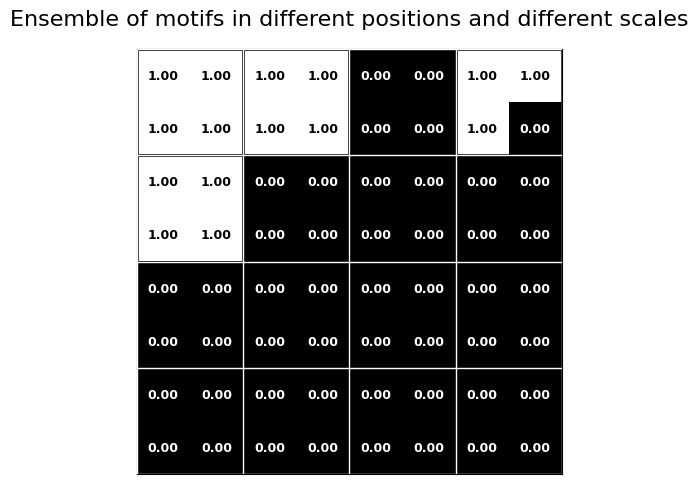

In [18]:
# create ensemble of motifs in different positions and different scales
mps_grid8x8_motif2x2_topright = [pos_R, pos_R, motif_tensor]

ensemble_mps = create_superposition_mps(
    mps_grid8x8_motif2x2_topright, mps_grid8x8_motif4x4_topleft
)
_, ensemble_grid8x8_2motif_diffScales_sameRot = plot_motif_reconstruction(
    ensemble_mps,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of motifs in different positions and different scales",
    return_raw_data=True,
    show_values=True,
    grid_step=2,
)

plt.savefig("plots/ensemble_from_tensors.png", dpi=600, bbox_inches="tight")

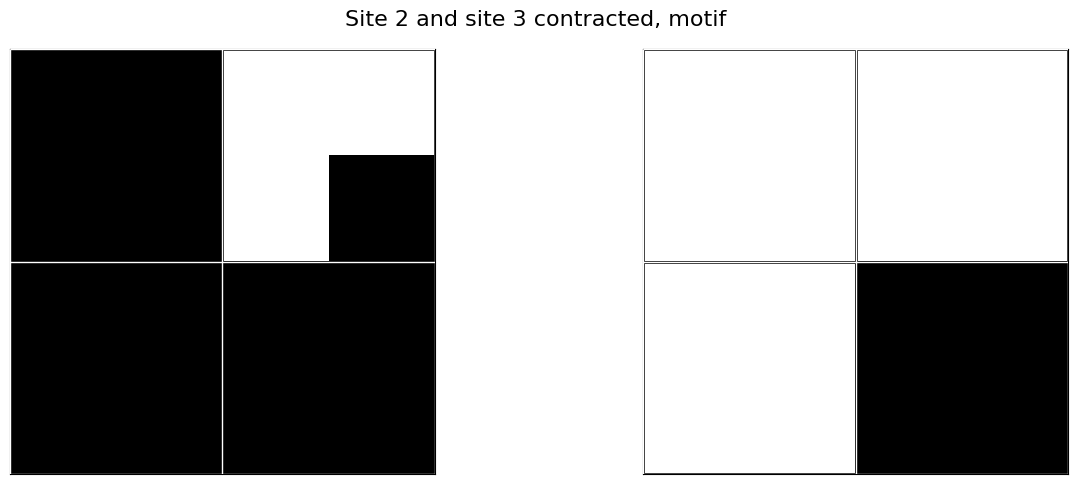

In [19]:
_, ensemble_grid8x8_2motif_diffScales_sameRot_recon_site2 = plot_motif_reconstruction(
    ensemble_mps,
    lambdas=madeup_lambda,
    depth=1,
    title="Site 2 and site 3 contracted, motif ",
    return_raw_data=True,
    show_values=False,
    grid_step=2,
)

plt.savefig("plots/ensemble_site2recon.png", dpi=300, bbox_inches="tight")

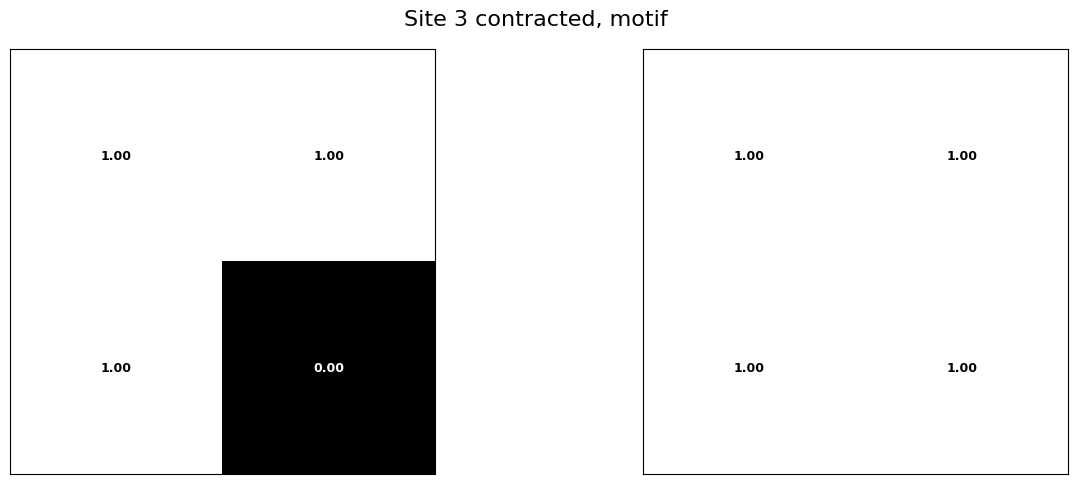

In [20]:
_, ensemble_grid8x8_2motif_diffScales_sameRot_recon_site3 = plot_motif_reconstruction(
    ensemble_mps,
    lambdas=madeup_lambda,
    depth=2,
    title="Site 3 contracted, motif ",
    return_raw_data=True,
)

plt.savefig("plots/ensemble_from_tensors_site3recon.png", dpi=300, bbox_inches="tight")

In [21]:
ensemble_mps

[array([[[0., 1.],
         [1., 0.],
         [0., 0.],
         [0., 0.]]]),
 array([[[0., 0.],
         [1., 0.],
         [0., 0.],
         [0., 0.]],
 
        [[0., 1.],
         [0., 1.],
         [0., 1.],
         [0., 0.]]]),
 array([[[1.],
         [1.],
         [1.],
         [0.]],
 
        [[1.],
         [1.],
         [1.],
         [1.]]])]

In [22]:
#  Shape ensemble
[t.shape for t in ensemble_mps]

[(1, 4, 2), (2, 4, 2), (2, 4, 1)]

In [23]:
ensemble_mps[1][0]

array([[0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.]])

In [24]:
target_row = ensemble_mps[1][
    0, :, 0
]  # second site, first block, all rows, first column
target_row

array([0., 1., 0., 0.])

In [25]:
ensemble_grid8x8_2motif_diffScales_sameRot_squeezed = np.squeeze(
    ensemble_grid8x8_2motif_diffScales_sameRot
)
ensemble_grid8x8_2motif_diffScales_sameRot_squeezed

array([[1., 1., 1., 1., 0., 0., 1., 1.],
       [1., 1., 1., 1., 0., 0., 1., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

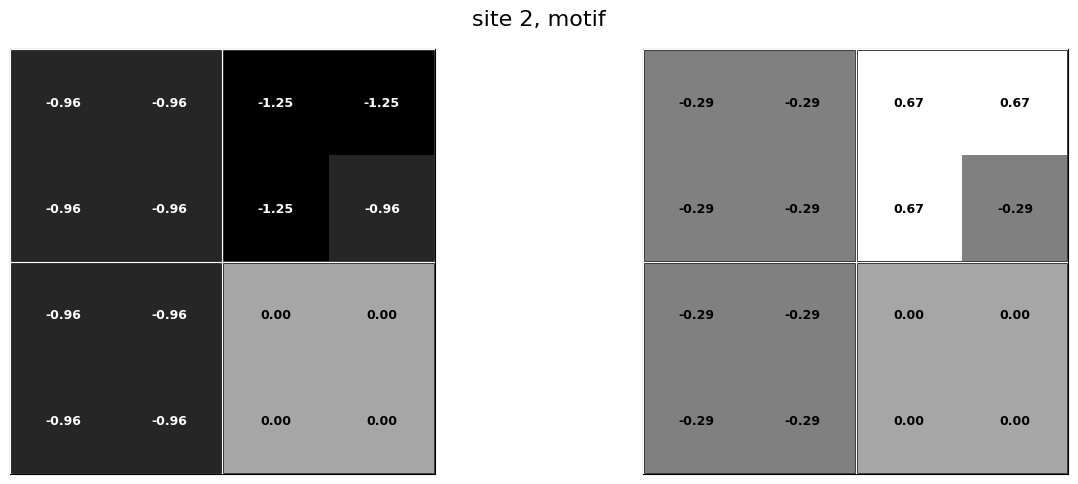

In [26]:
# encode grid into mps and reconstruct from mps
hierarchical_motif = image_to_hierarchical(
    ensemble_grid8x8_2motif_diffScales_sameRot_squeezed
)
ensemble_mps_from_image, lambdas_ensemble = dense_to_mps_L_canonical(
    hierarchical_motif, physical_dim=4, bond_dim=2
)
ensemble_grid_from_image = plot_motif_reconstruction(
    ensemble_mps_from_image,
    lambdas=lambdas_ensemble,
    depth=1,
    title="site 2, motif",
    show_values=True,
    grid_step=2,
)

plt.savefig("plots/grid_mps_recon_site2.png", dpi=300, bbox_inches="tight")

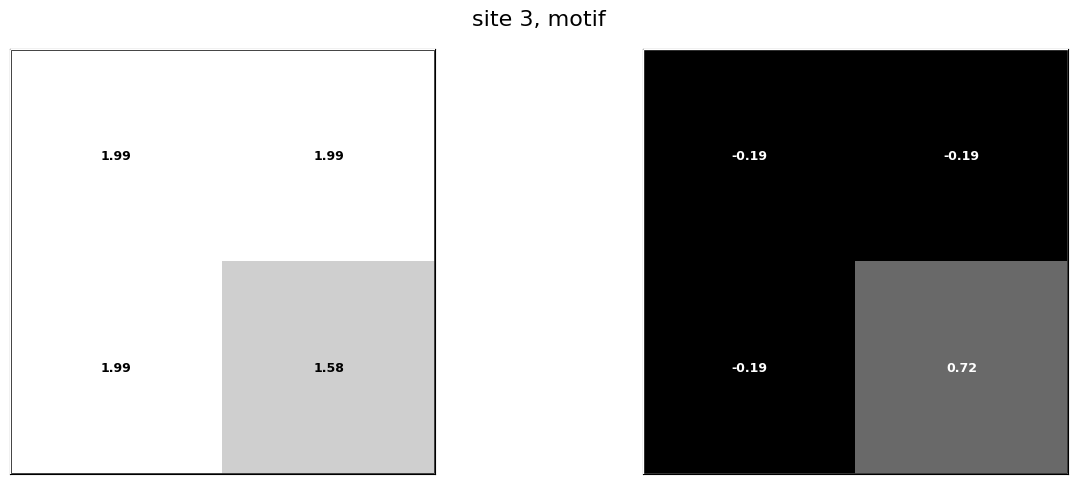

In [27]:
ensemble_mps_from_image, lambdas_ensemble = dense_to_mps_L_canonical(
    hierarchical_motif, physical_dim=4, bond_dim=2
)
ensemble_grid_from_image = plot_motif_reconstruction(
    ensemble_mps_from_image,
    lambdas=lambdas_ensemble,
    depth=2,
    title="site 3, motif",
    show_values=True,
    grid_step=2,
)
plt.savefig("plots/grid_mps_recon_site3.png", dpi=300, bbox_inches="tight")

In [28]:
# raise SystemExit("Stopping execution here")

# 2 motifs, same scale, same orientation 

In [29]:
mps_grid4x4_motif2x2_topleft = [
    position_tensor,
    motif_tensor,
]
mps_grid4x4_motif2x2_topright = [
    pos_R,
    motif_tensor,
]

ensemble_grid4x4_2Mofits_sameScale_sameRot = create_superposition_mps(
    mps_grid4x4_motif2x2_topleft, mps_grid4x4_motif2x2_topright
)

In [30]:
# shape of each site
for i, mps in enumerate(ensemble_grid4x4_2Mofits_sameScale_sameRot):
    print(f"Site {i} shape: {mps.shape}")

Site 0 shape: (1, 4, 1)
Site 1 shape: (1, 4, 1)


$$ 
\begin{pmatrix} p & pR \end{pmatrix}
    \begin{pmatrix} 
    m \\ 
    m
    \end{pmatrix}
    $$

compressed:
$$ |\Psi\rangle = |p + pR\rangle \otimes |m\rangle \iff
\begin{pmatrix} p + pR \end{pmatrix}
    \begin{pmatrix} 
    m  
    \end{pmatrix}
    $$

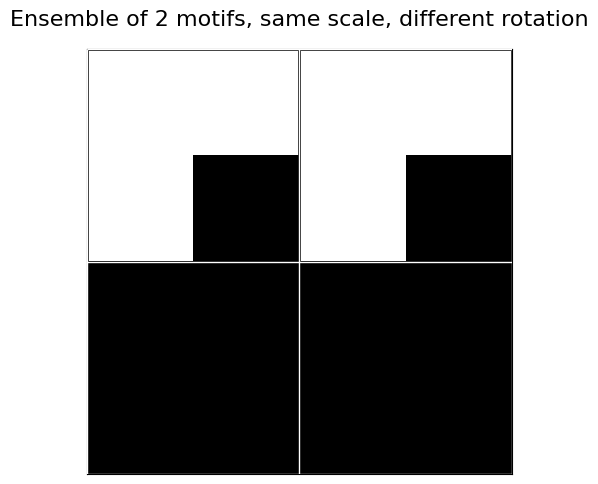

In [31]:
# recon from mps
_, ensemble_grid4x4_2Mofits_sameScale_sameRot_recon = plot_motif_reconstruction(
    ensemble_grid4x4_2Mofits_sameScale_sameRot,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 2 motifs, same scale, different rotation",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="ensemble_grid4x4_2Mofits_sameScale_sameRot.png",
)

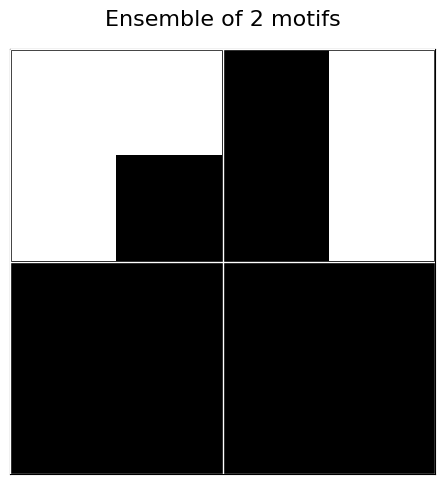

In [32]:
# line shape
vline_tensor = np.array([[[0.0], [1.0], [0.0], [1.0]]])
ensemble_grid4x4_2Mofits = [
    position_tensor,
    motif_tensor,
]
mps_grid4x4_motif2x2_topright_line = [
    pos_R,
    vline_tensor,
]

ensemble_grid4x4_2Mofits_sameScale_sameRot = create_superposition_mps(
    mps_grid4x4_motif2x2_topleft, mps_grid4x4_motif2x2_topright_line
)

_, ensemble_grid4x4_2Mofits_sameScale_sameRot_recon = plot_motif_reconstruction(
    ensemble_grid4x4_2Mofits_sameScale_sameRot,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 2 motifs",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="ensemble_grid4x4_2Mofits_lshape_lineshape.png",
)

## 2 Motif, Same scale, diff. orientation
The below can be represented by:

 
$$ 
\begin{pmatrix} p & pR \end{pmatrix}
    \begin{pmatrix} 
    m \\ 
    mR 
    \end{pmatrix}
    $$

In [33]:
mps_grid4x4_motif2x2_topright_rot = [
    pos_R,
    motif_R,
]

ensemble_grid4x4_2Mofits_sameScale_diffRot = create_superposition_mps(
    mps_grid4x4_motif2x2_topleft, mps_grid4x4_motif2x2_topright_rot
)

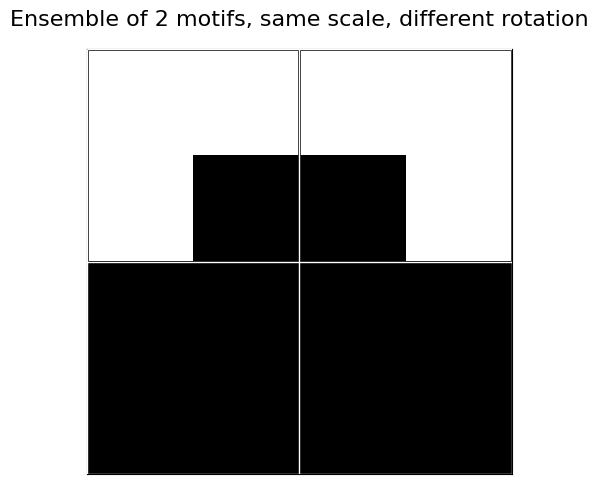

In [34]:
# recon from mps
_, ensemble_grid4x4_2Mofits_sameScale_diffRot_recon = plot_motif_reconstruction(
    ensemble_grid4x4_2Mofits_sameScale_diffRot,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 2 motifs, same scale, different rotation",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="ensemble_grid4x4_2Mofits_sameScale_diffRot.png",
)

# 3 motifs, diff scales, same rotations


$$\begin{aligned}
|\psi_1\rangle &= |P\rangle \otimes R|P\rangle \otimes R^2|M\rangle \\
|\psi_2\rangle &= R^2|P\rangle \otimes R^2|M\rangle \otimes |F\rangle \\
|\psi_3\rangle &= R^3|P\rangle \otimes R^2|M\rangle \otimes |F\rangle
\end{aligned}$$


Sum state:
$$|\Psi\rangle = |P\rangle \otimes R|P\rangle \otimes R^2|M\rangle + R^2|P\rangle \otimes R^2|M\rangle \otimes |F\rangle + R^3|P\rangle \otimes R^2|M\rangle \otimes |F\rangle$$


The above is equivalent to:
$$
|\Psi\rangle = \sum_{\sigma_0,\sigma_1,\sigma_2} \left( \sum_{b_1,b_2} A^{[0]}_{0,\sigma_0,b_1} \cdot A^{[1]}_{b_1,\sigma_1,b_2} \cdot A^{[2]}_{b_2,\sigma_2,0} \right) |\sigma_0, \sigma_1, \sigma_2\rangle
$$

where:
$$A^{[0]} = \begin{pmatrix} |P\rangle & R^2|P\rangle & R^3|P\rangle \end{pmatrix}, \quad A^{[1]} = \begin{pmatrix} R|P\rangle & 0 & 0 \\ 0 & R^2|M\rangle & 0 \\ 0 & 0 & R^2|M\rangle \end{pmatrix}, \quad A^{[2]} = \begin{pmatrix} R^2|M\rangle \\ |F\rangle \\ |F\rangle \end{pmatrix}$$



---


### compressed version 
$$A^{[0]} = \begin{pmatrix} |P\rangle & (R^2 + R^3)|P\rangle \end{pmatrix}, \quad 
A^{[1]} = \begin{pmatrix} R|P\rangle & 0 \\ 0 & R^2|M\rangle \end{pmatrix}, \quad 
A^{[2]} = \begin{pmatrix} R^2|M\rangle \\ |F\rangle \end{pmatrix}$$

Which equal to 
$$\begin{aligned}
|\Psi\rangle &= |\psi_1\rangle + |\psi_2\rangle \\
|\psi_1\rangle &= |P\rangle \otimes R|P\rangle \otimes R^2|M\rangle \\
|\psi_2\rangle &= (R^2 + R^3)|P\rangle \otimes R^2|M\rangle \otimes |F\rangle
\end{aligned}$$

MPS 1:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
MPS 2:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
MPS 3:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
Site 0 shape: (1, 4, 2)
Site 1 shape: (2, 4, 2)
Site 2 shape: (2, 4, 1)


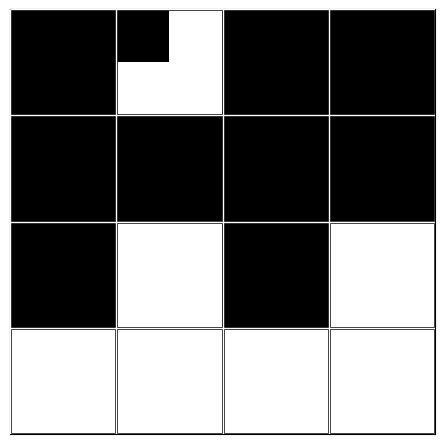

In [35]:
mps1 = [position_tensor, pos_R, motif_RR]
mps2 = [pos_RR, motif_RR, filler_tensor]
mps3 = [pos_RRR, motif_RR, filler_tensor]

# shape of each mps
for i, mps in enumerate([mps1, mps2, mps3]):
    print(f"MPS {i + 1}:")
    for j, site in enumerate(mps):
        print(f"  Site {j} shape: {site.shape}")

mps_grouped = [mps1, mps2, mps3]

ensemble_grid8x8_2Mofits_diffScale_sameRot = create_superposition_mps(*mps_grouped)

# shape mps
for i, mps in enumerate(ensemble_grid8x8_2Mofits_diffScale_sameRot):
    print(f"Site {i} shape: {mps.shape}")

_, ensemble_grid8x8_2Mofits_diffScale_sameRot_recon = plot_motif_reconstruction(
    ensemble_grid8x8_2Mofits_diffScale_sameRot,
    lambdas=madeup_lambda,
    depth=0,
    # title="Ensemble of 2 motifs, different scale, same rotation",
    title=False,
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="ensemble_grid8x8_3Mofits_diffScale_sameRot.png",
)

## Simplefied vertion of the above



$$\begin{aligned}
|\psi_1\rangle &= |P\rangle \otimes R|P\rangle \otimes |M\rangle \\
|\psi_2\rangle &= R^2|P\rangle \otimes |M\rangle \otimes |F\rangle \\
|\psi_3\rangle &= R^3|P\rangle \otimes |M\rangle \otimes |F\rangle
\end{aligned}$$


Sum state:
$$|\Psi\rangle = |P\rangle \otimes R|P\rangle \otimes |M\rangle + R^2|P\rangle \otimes |M\rangle \otimes |F\rangle + R^3|P\rangle \otimes |M\rangle \otimes |F\rangle$$


The above is equivalent to:
$$
|\Psi\rangle = \sum_{\sigma_0,\sigma_1,\sigma_2} \left( \sum_{b_1,b_2} A^{[0]}_{0,\sigma_0,b_1} \cdot A^{[1]}_{b_1,\sigma_1,b_2} \cdot A^{[2]}_{b_2,\sigma_2,0} \right) |\sigma_0, \sigma_1, \sigma_2\rangle
$$

where:
$$A^{[0]} = \begin{pmatrix} |P\rangle & R^2|P\rangle & R^3|P\rangle \end{pmatrix}, \quad A^{[1]} = \begin{pmatrix} R|P\rangle & 0 & 0 \\ 0 & |M\rangle & 0 \\ 0 & 0 & |M\rangle \end{pmatrix}, \quad A^{[2]} = \begin{pmatrix} |M\rangle \\ |F\rangle \\ |F\rangle \end{pmatrix}$$



---


### compressed version 
$$A^{[0]} = \begin{pmatrix} |P\rangle & (R^2 + R^3)|P\rangle \end{pmatrix}, \quad 
A^{[1]} = \begin{pmatrix} R|P\rangle & 0 \\ 0 & |M\rangle \end{pmatrix}, \quad 
A^{[2]} = \begin{pmatrix}|M\rangle \\ |F\rangle \end{pmatrix}$$

Which equal to 
$$\begin{aligned}
|\Psi\rangle &= |\psi_1\rangle + |\psi_2\rangle \\
|\psi_1\rangle &= |P\rangle \otimes R|P\rangle \otimes |M\rangle \\
|\psi_2\rangle &= (R^2 + R^3)|P\rangle \otimes |M\rangle \otimes |F\rangle
\end{aligned}$$


MPS 1:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
MPS 2:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
MPS 3:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
Site 0 shape: (1, 4, 2)
Site 1 shape: (2, 4, 2)
Site 2 shape: (2, 4, 1)


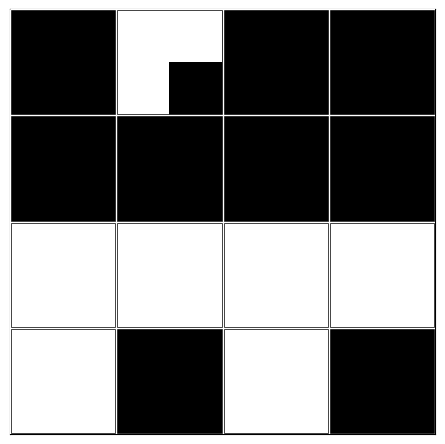

In [36]:
mps1 = [position_tensor, pos_R, motif_tensor]
mps2 = [pos_RR, motif_tensor, filler_tensor]
mps3 = [pos_RRR, motif_tensor, filler_tensor]

# shape of each mps
for i, mps in enumerate([mps1, mps2, mps3]):
    print(f"MPS {i + 1}:")
    for j, site in enumerate(mps):
        print(f"  Site {j} shape: {site.shape}")

mps_grouped_simplefied = [mps1, mps2, mps3]

ensemble_grid8x8_2Mofits_diffScale_sameRot = create_superposition_mps(
    *mps_grouped_simplefied
)

# shape mps
for i, mps in enumerate(ensemble_grid8x8_2Mofits_diffScale_sameRot):
    print(f"Site {i} shape: {mps.shape}")

_, ensemble_grid8x8_2Mofits_diffScale_sameRot_recon = plot_motif_reconstruction(
    ensemble_grid8x8_2Mofits_diffScale_sameRot,
    lambdas=madeup_lambda,
    depth=0,
    # title="Ensemble of 2 motifs, different scale, same rotation",
    title=False,
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="ensemble_grid8x8_2Mofits_diffScale_sameRot_simplified.png",
)

# 3 Motifs, diff scale, diff orientations
$$
A^{[0]} = \begin{pmatrix} |P\rangle & R^2|P\rangle & R^3|P\rangle \end{pmatrix}, \quad 
A^{[1]} = \begin{pmatrix} R|P\rangle & 0 & 0 \\ 0 & R^2|M\rangle & 0 \\ 0 & 0 & R^3|M\rangle \end{pmatrix}, \quad 
A^{[2]} = \begin{pmatrix} R^2|M\rangle \\ |F\rangle \\ |F\rangle \end{pmatrix}
$$


### compressed version

$$
A^{[0]} =\begin{pmatrix} |P\rangle & R^2|P\rangle & R^3|P\rangle \end{pmatrix} , \quad 
A^{[1]} =\begin{pmatrix}
    R|P\rangle & 0   \\
    0 & R^2|M\rangle \\
    0 & R^3|M\rangle
\end{pmatrix} , \quad 
A^{[2]} =\begin{pmatrix}
    R^2|M\rangle \\
    |F\rangle
\end{pmatrix}
$$


## <span style="color:red"> THEOREM </span>
### Definition: Suffix Equivalence

For two MPS, $k$ and $\ell$, are defined as suffix-equivalent at site $i$ if their constituent tensors are identical for all sites from $i$ to the end of the chain of lenth $L$: $$A_k^{[j]} = A_\ell^{[j]} \quad \forall j \in \{i, \dots, L\}$$

---

### Maximum Lossless Compression Lemma
For a Sum state made up of N MPS, the minimal bond dimension, $D_i^{min}$ connecting sites i and i+1 that represents the superposition exactly is:

$$ D_i^{\min} = \left| \mathcal{S}_i \right| $$

where $\mathcal{S}_i $ is the set of distinct suffixes:
$$
\begin{equation}
\mathcal{S}_i = \left\{ \{ A_{\alpha}^{[i+1]}, \dots, A_{\alpha}^{[L]}\} : \alpha \in [1, N] \right\} 
\end{equation}
$$
That is, $D_k^{\min}$ equals the $\textbf{number of distinct suffixes}$ starting from site $i+1$.

<!-- ## <span style="color:red"> Write how the compressed sum state is created </span> -->


MPS 1:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
MPS 2:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
MPS 3:
  Site 0 shape: (1, 4, 1)
  Site 1 shape: (1, 4, 1)
  Site 2 shape: (1, 4, 1)
Site 0 shape: (1, 4, 3)
Site 1 shape: (3, 4, 2)
Site 2 shape: (2, 4, 1)


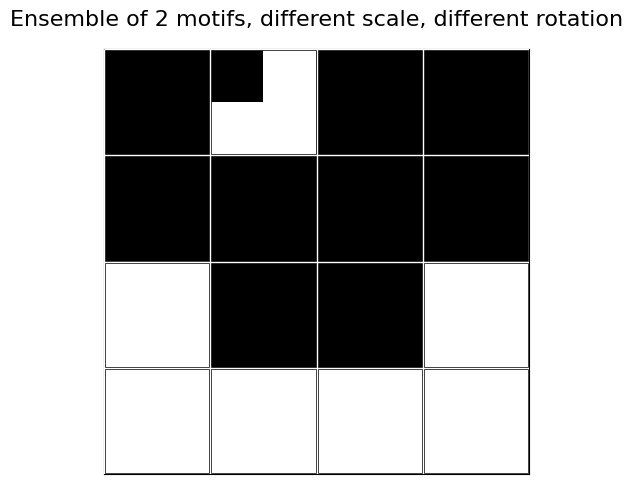

In [37]:
mps1 = [position_tensor, pos_R, motif_RR]
mps2 = [pos_RR, motif_RR, filler_tensor]
mps3 = [pos_RRR, motif_RRR, filler_tensor]

# shape of each mps
for i, mps in enumerate([mps1, mps2, mps3]):
    print(f"MPS {i + 1}:")
    for j, site in enumerate(mps):
        print(f"  Site {j} shape: {site.shape}")

mps_grouped = [mps1, mps2, mps3]

ensemble_grid8x8_2Mofits_diffScale_diffRot = create_superposition_mps(*mps_grouped)

# shape mps
for i, mps in enumerate(ensemble_grid8x8_2Mofits_diffScale_diffRot):
    print(f"Site {i} shape: {mps.shape}")

_, ensemble_grid8x8_2Mofits_diffScale_diffRot_recon = plot_motif_reconstruction(
    ensemble_grid8x8_2Mofits_diffScale_diffRot,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 2 motifs, different scale, different rotation",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="ensemble_grid8x8_3Mofits_diffScale_diffRot.png",
)

In [38]:
for i, mps in enumerate(ensemble_grid8x8_2Mofits_diffScale_diffRot):
    print(f"Site {i}")
    print(f" {mps}")
    print("--------")

Site 0
 [[[1. 0. 0.]
  [0. 0. 0.]
  [0. 0. 1.]
  [0. 1. 0.]]]
--------
Site 1
 [[[0. 0.]
  [1. 0.]
  [0. 0.]
  [0. 0.]]

 [[0. 0.]
  [0. 1.]
  [0. 1.]
  [0. 1.]]

 [[0. 1.]
  [0. 0.]
  [0. 1.]
  [0. 1.]]]
--------
Site 2
 [[[0.]
  [1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]
  [1.]]]
--------


## Half 2x2cell traslation of a 2x2 motif 
Single L motif with offsets, such that shape is on the boundaries, Encode as multiple motifs 

In [39]:
# new set of basic motif
m1 = np.array([[[1], [0], [0], [0]]])
m2 = np.array([[[1], [1], [0], [0]]])

m1_R = ncon([m1, rot_90], [[-1, 1, -3], [-2, 1]])
m1_RR = ncon([m1_R, rot_90], [[-1, 1, -3], [-2, 1]])
m1_RRR = ncon([m1_RR, rot_90], [[-1, 1, -3], [-2, 1]])

m2_R = ncon([m2, rot_90], [[-1, 1, -3], [-2, 1]])
m2_RR = ncon([m2_R, rot_90], [[-1, 1, -3], [-2, 1]])
m2_RRR = ncon([m2_RR, rot_90], [[-1, 1, -3], [-2, 1]])

# motif used in previous sections can be made using m1 and m2

m3 = [m1_RRR + m2]
m3

[array([[[1],
         [1],
         [1],
         [0]]])]

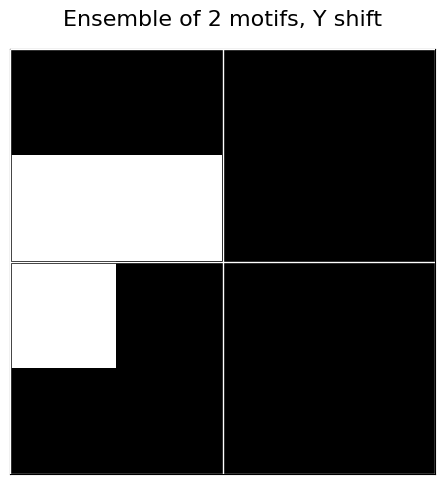

In [40]:
# motif shifted in Y direction
mps1 = [position_tensor, m2_RR]
mps2 = [pos_RRR, m1]
mps_grouped = [mps1, mps2]

ensenble_grid4x4_Yoffset = create_superposition_mps(*mps_grouped)

_, ensenble_grid4x4_Yoffset_recon = plot_motif_reconstruction(
    ensenble_grid4x4_Yoffset,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 2 motifs, Y shift",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="grid4x4_motif2x2_Yoffset.png",
)

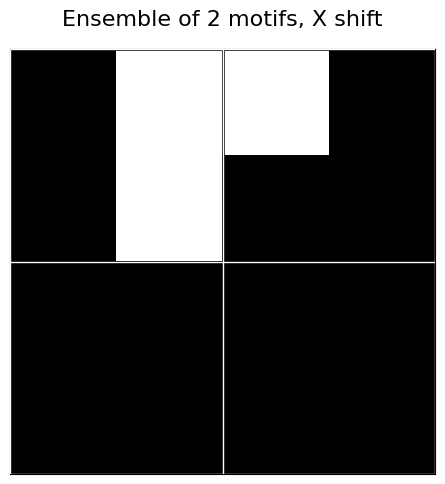

In [41]:
# motif shifted in X direction
mps1 = [position_tensor, m2_R]
mps2 = [pos_R, m1]

mps_grouped = [mps1, mps2]
ensenble_grid4x4_Xoffset = create_superposition_mps(*mps_grouped)
_, ensenble_grid4x4_Xoffset_recon = plot_motif_reconstruction(
    ensenble_grid4x4_Xoffset,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 2 motifs, X shift",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="grid4x4_motif2x2_Xoffset.png",
)

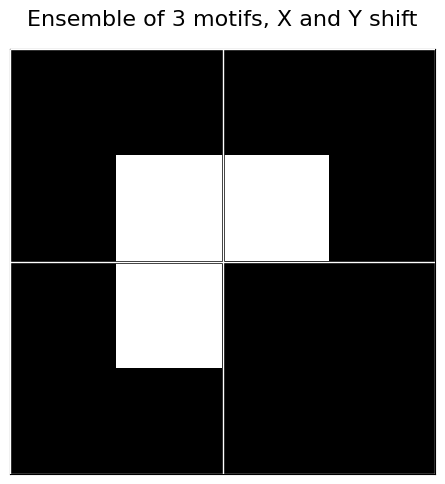

In [42]:
# motif shifted in X and Y direction
mps1 = [position_tensor, m1_RR]
mps2 = [pos_R, m1_RRR]
mps3 = [pos_RRR, m1_R]

mps_grouped = [mps1, mps2, mps3]
ensenble_grid4x4_XYoffset = create_superposition_mps(*mps_grouped)
_, ensenble_grid4x4_XYoffset_recon = plot_motif_reconstruction(
    ensenble_grid4x4_XYoffset,
    lambdas=madeup_lambda,
    depth=0,
    title="Ensemble of 3 motifs, X and Y shift",
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="grid4x4_motif2x2_XYoffset.png",
)

### horizontal bar traslation 

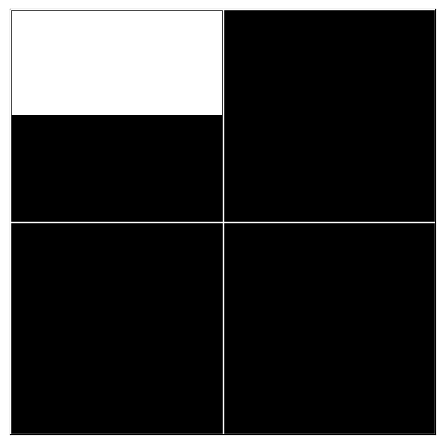

In [43]:
mps1 = [position_tensor, m2]

_, ensenble_grid4x4_Xoffset_hbar = plot_motif_reconstruction(
    mps1,
    lambdas=madeup_lambda,
    depth=0,
    # title="Ensemble of 3 motifs, X and Y shift",
    title=False,
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="grid4x4_motif2x1_bar_pos1.png",
)

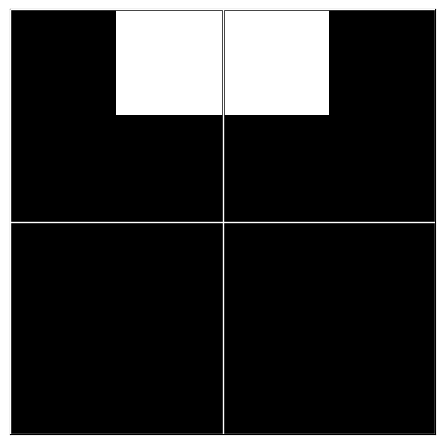

In [44]:
mps2 = [position_tensor, m1_R]
mps3 = [pos_R, m1]

ensemble_bar = create_superposition_mps(mps2, mps3)


_, ensenble_grid4x4_Xoffset_hbar = plot_motif_reconstruction(
    ensemble_bar,
    lambdas=madeup_lambda,
    depth=0,
    # title="Ensemble of 3 motifs, X and Y shift",
    title=False,
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="grid4x4_motif2x1_bar_pos2.png",
)

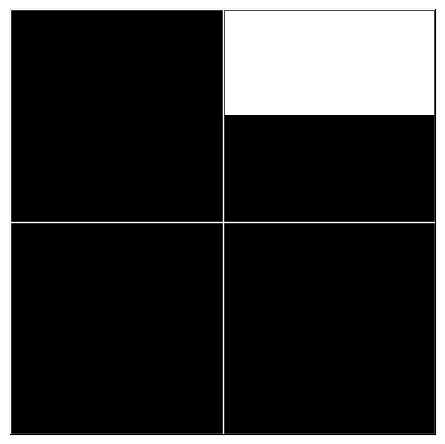

In [45]:
mps4 = [pos_R, m2]


_, ensenble_grid4x4_Xoffset_hbar = plot_motif_reconstruction(
    mps4,
    lambdas=madeup_lambda,
    depth=0,
    # title="Ensemble of 3 motifs, X and Y shift",
    title=False,
    show_values=False,
    grid_step=2,
    return_raw_data=True,
    filename="grid4x4_motif2x1_bar_pos3.png",
)

# ignore section

# encoding 4x4 motif on 8x8 grid that is placed between Boundaries  

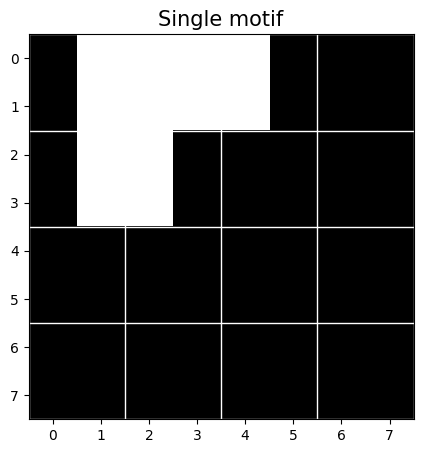

In [46]:
size_motif = 4
motif0 = np.ones((size_motif, size_motif))
motif0[2, 2] = 0
motif0[2, 3] = 0
motif0[3, 2] = 0
motif0[3, 3] = 0

row_start = 0
col_start = 1
exponent_size = 3

grid = create_grid(
    motif0, exponent_size=exponent_size, row_offset=row_start, col_offset=col_start
)

plot_save_grid(
    grid,
    title="Single motif",
    filename="4x4motif_Xoffset",
    cell_size=2,
)

In [47]:
# encode and reconstruct
hierarchical_motif = image_to_hierarchical(grid)
grid_mps, lambdas_motif = dense_to_mps_L_canonical(
    hierarchical_motif, physical_dim=4, bond_dim=2
)
print("Shape of each site in MPS:", [t.shape for t in grid_mps])

Shape of each site in MPS: [(1, 4, 2), (2, 4, 2), (2, 4, 1)]


In [48]:
print("each site in MPS:")
for i, t in enumerate(grid_mps):
    print(f"Site {i}:")
    print(np.array2string(t, formatter={"float_kind": lambda x: f"{x:.3f}"}))
    print()

each site in MPS:
Site 0:
[[[1.000 0.000]
  [0.000 1.000]
  [0.000 0.000]
  [0.000 0.000]]]

Site 1:
[[[-0.354 0.500]
  [-0.707 -0.000]
  [-0.354 0.500]
  [-0.354 -0.500]]

 [[-0.354 -0.500]
  [0.000 -0.000]
  [0.000 -0.000]
  [0.000 0.000]]]

Site 2:
[[[-0.408]
  [-0.408]
  [-0.408]
  [-0.408]]

 [[-0.289]
  [0.289]
  [-0.289]
  [0.289]]]



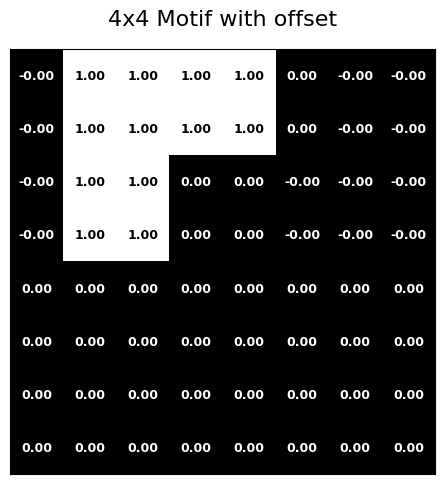

In [49]:
# reconstruct
recon_motif = plot_motif_reconstruction(
    grid_mps, lambdas=lambdas_motif, depth=0, title="4x4 Motif with offset"
)

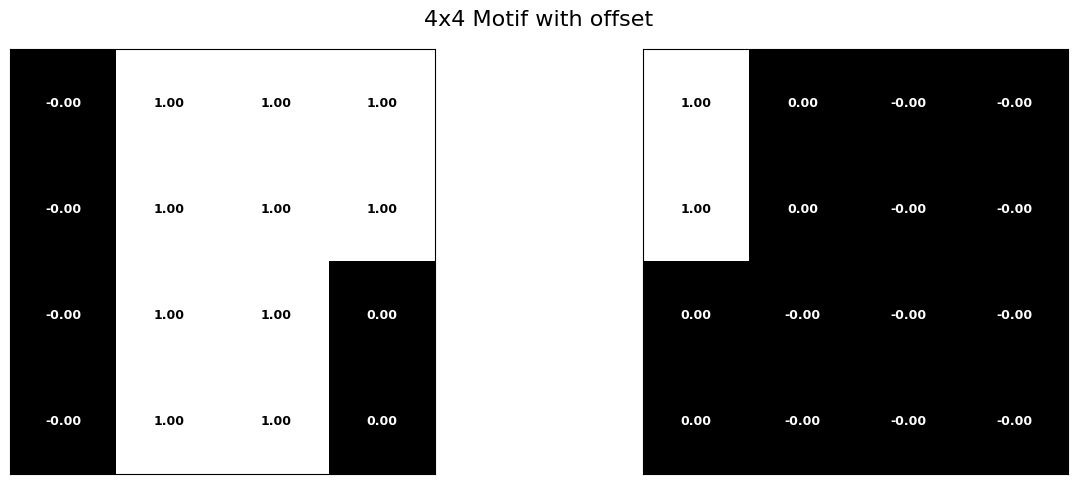

In [50]:
# reconstruct
recon_motif = plot_motif_reconstruction(
    grid_mps, lambdas=lambdas_motif, depth=1, title="4x4 Motif with offset"
)
plt.savefig("plots/4x4motif_offset1_site2recon.png", dpi=300, bbox_inches="tight")

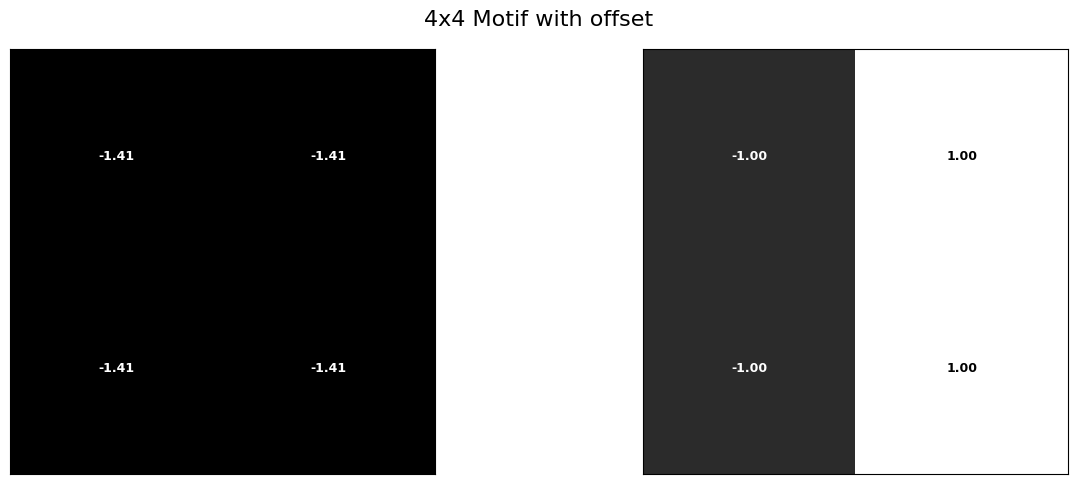

In [51]:
# reconstruct
recon_motif = plot_motif_reconstruction(
    grid_mps, lambdas=lambdas_motif, depth=2, title="4x4 Motif with offset"
)

plt.savefig("plots/4x4motif_offset1_site3recon.png", dpi=300, bbox_inches="tight")

In [52]:
lambdas_motif

[array([3.16227766, 1.41421356]),
 array([2.82842712, 2.        ]),
 array([3.46410162])]

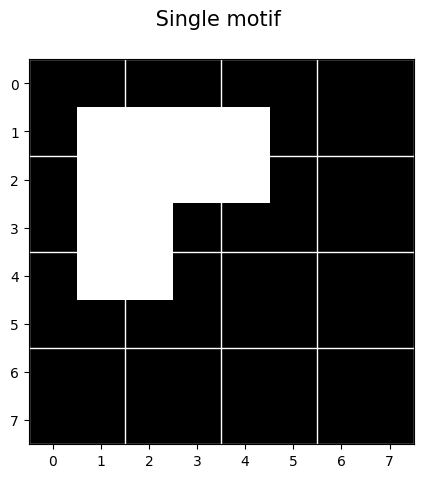

In [53]:
# create motif
size_motif = 4
motif0 = np.ones((size_motif, size_motif))
motif0[2, 2] = 0
motif0[2, 3] = 0
motif0[3, 2] = 0
motif0[3, 3] = 0
motif0


cell_size = 2
grid_size = 2
grid = np.zeros((grid_size * 4, grid_size * 4))


# motif in top left corner only
row_start = 0
col_start = 0
grid[
    row_start + 1 : row_start + size_motif + 1,
    col_start + 1 : col_start + size_motif + 1,
] = motif0


fig_single_motif, ax = plt.subplots(1, figsize=(5, 5))
fig_single_motif.suptitle(" Single motif", fontsize=15)

ax.imshow(grid, cmap="gray")

point_indices = np.arange(grid.shape[0])
ax.set_xticks(point_indices)
ax.set_yticks(point_indices)

# gridlines
cell_boundaries = np.arange(-0.5, grid.shape[0], cell_size)
ax.set_xticks(cell_boundaries, minor=True)
ax.set_yticks(cell_boundaries, minor=True)

ax.grid(which="minor", color="white", linestyle="-", linewidth=1, alpha=1)

ax.tick_params(which="major", bottom=True, left=True, labelbottom=True, labelleft=True)
ax.tick_params(which="minor", bottom=False, left=False)

plt.savefig("plots/single_motif.png", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
# encode and reconstruct
hierarchical_motif = image_to_hierarchical(grid)
grid_mps, lambdas_motif = dense_to_mps_L_canonical(
    hierarchical_motif, physical_dim=4, bond_dim=4
)
print("Shape of each site in MPS:", [t.shape for t in grid_mps])

print("each site in MPS:")
for i, t in enumerate(grid_mps):
    print(f"Site {i}:")
    print(np.array2string(t, formatter={"float_kind": lambda x: f"{x:.3f}"}))
    print()

Shape of each site in MPS: [(1, 4, 4), (4, 4, 4), (4, 4, 1)]
each site in MPS:
Site 0:
[[[1.000 0.000 0.000 0.000]
  [0.000 1.000 0.000 0.000]
  [0.000 0.000 1.000 0.000]
  [0.000 0.000 0.000 1.000]]]

Site 1:
[[[-0.185 0.408 0.000 -0.465]
  [-0.421 0.408 -0.500 -0.102]
  [-0.421 0.408 0.500 -0.102]
  [-0.657 -0.408 -0.000 0.261]]

 [[-0.236 0.000 -0.500 0.363]
  [0.000 0.000 0.000 0.000]
  [-0.185 -0.408 0.000 -0.465]
  [0.000 0.000 0.000 0.000]]

 [[-0.236 0.000 0.500 0.363]
  [-0.185 -0.408 0.000 -0.465]
  [0.000 0.000 -0.000 0.000]
  [0.000 0.000 0.000 0.000]]

 [[0.000 0.000 0.000 0.000]
  [0.000 0.000 0.000 0.000]
  [0.000 0.000 0.000 0.000]
  [0.000 0.000 0.000 0.000]]]

Site 2:
[[[-0.296]
  [-0.379]
  [-0.379]
  [-0.296]]

 [[-0.354]
  [-0.000]
  [0.000]
  [0.354]]

 [[0.000]
  [0.289]
  [-0.289]
  [0.000]]

 [[-0.193]
  [0.151]
  [0.151]
  [-0.193]]]



In [55]:
lambdas_motif

[array([2.82842712, 1.41421356, 1.41421356, 0.        ]),
 array([2.35829447, 1.73205081, 1.41421356, 1.19935282]),
 array([3.46410162])]

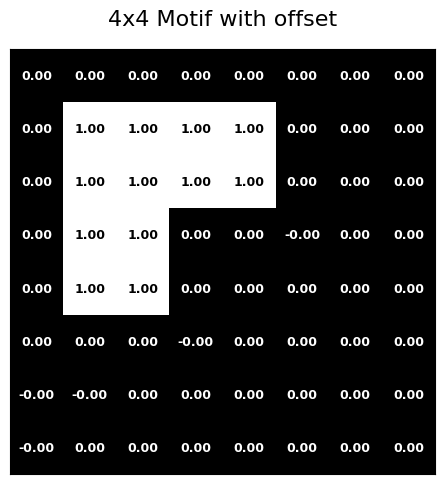

In [56]:
# reconstruct
recon_motif = plot_motif_reconstruction(
    grid_mps, lambdas=lambdas_motif, depth=0, title="4x4 Motif with offset"
)

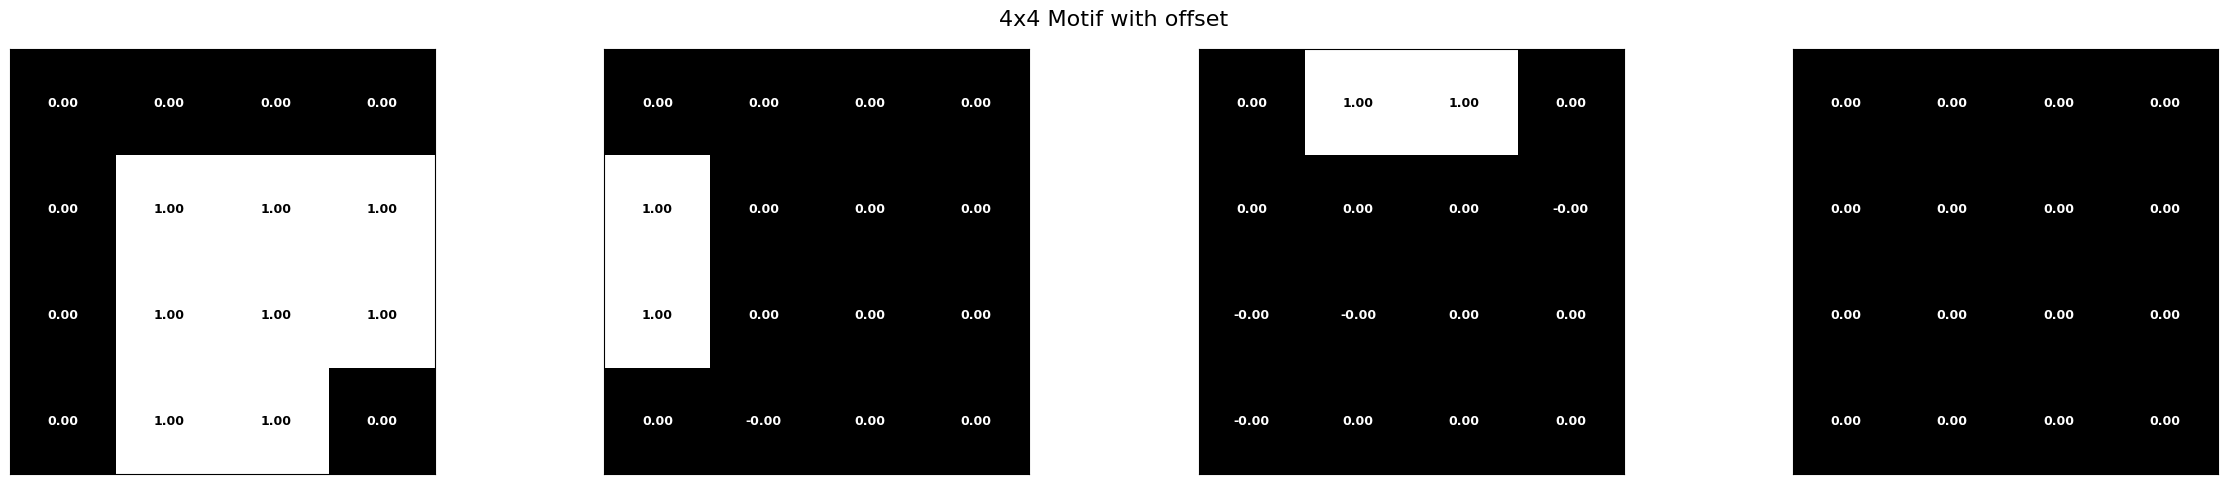

In [57]:
# reconstruct
recon_motif = plot_motif_reconstruction(
    grid_mps, lambdas=lambdas_motif, depth=1, title="4x4 Motif with offset"
)

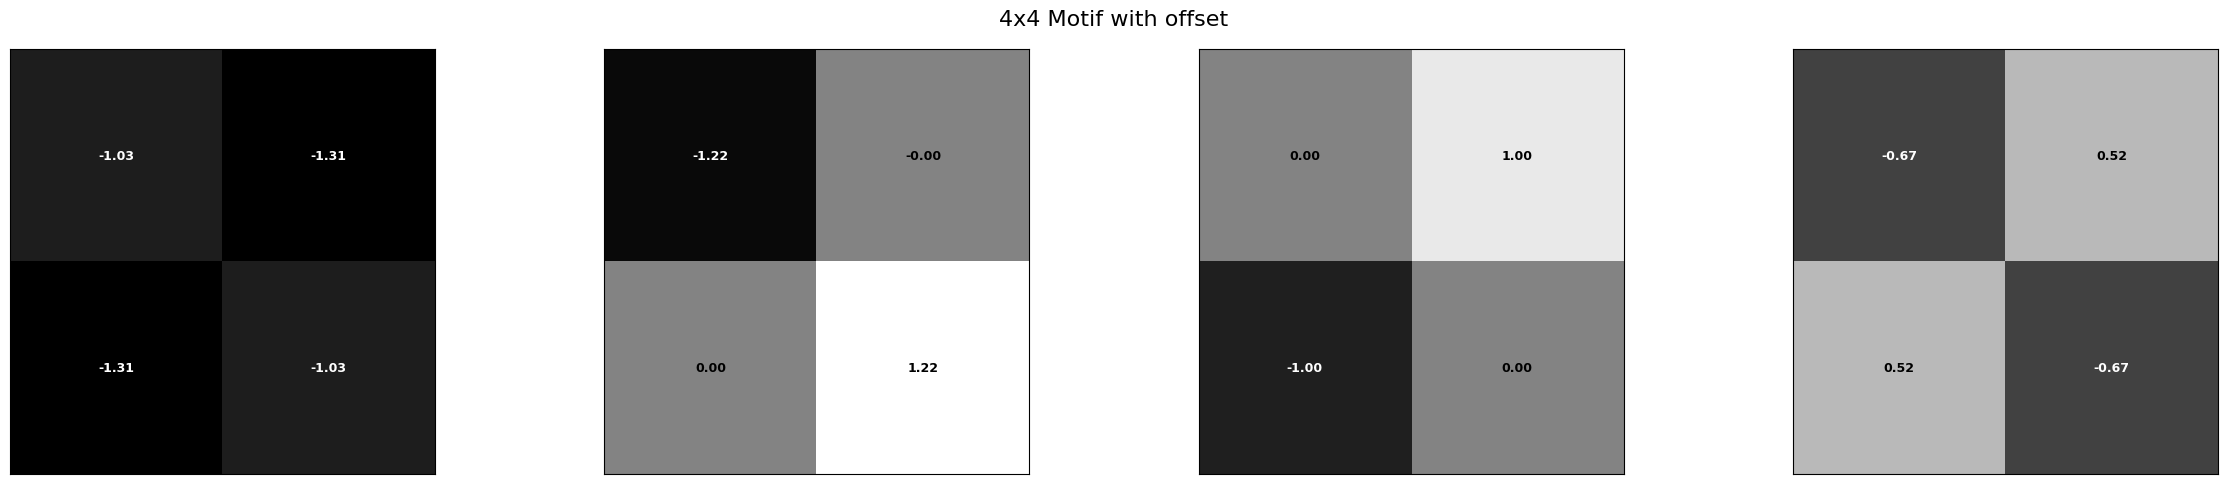

In [58]:
# reconstruct
recon_motif = plot_motif_reconstruction(
    grid_mps, lambdas=lambdas_motif, depth=2, title="4x4 Motif with offset"
)